<a href="https://colab.research.google.com/github/soumnemishra/snap_tune/blob/main/Snap_tune_project_model_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install tensorflow scikit-learn opencv-python-headless tqdm -q

In [17]:
import os #OS FOR NAVIGATING THROUGH THE FILES
import matplotlib.pyplot as plt #MATPLOTLIB FOR PLOTTING GRAPHS
import seaborn as sns #SEABORN FOR DATA VISUALIZATION
from PIL import Image #PILLOW FOR IMAGE PROCESSING
import pandas as pd #PANDAS FOR data manipulation and data analysis
import numpy as np #NUMPY FOR NUMERICAL OPERATIONS

import hashlib #HASHLIB FOR CHECKING DUPLICATES
from collections import defaultdict #DEFAULTDICT FOR CREATING A DICTIONARY WITH DEFAULT VALUES



import tensorflow as tf
from tensorflow.keras.applications import resnet50
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

import glob


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ORIGINAL DATA SETS

# Acessing the total folders

In [4]:
Trainign_='/content/drive/MyDrive/snap_tune_project/original_datasets/train' #TRAINING FOLDER
Testing_='/content/drive/MyDrive/snap_tune_project/original_datasets/test' #TESTING FOLDER

# TRAINING FOLDER

In [5]:

#the base folder
base_folder = Trainign_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
counts = {}
total_images = 0 # Initialize a counter for the total number of images

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count
    total_images += count # Add the count from each class to the total

print(f"Total number of images in {Trainign_}: {total_images}") # Print the total count

#print the counts per class as before if you still need them
print(counts)

Total number of images in /content/drive/MyDrive/snap_tune_project/original_datasets/train: 28729
{'angry': 4005, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3181}


# CHECKING FOR DUPLICATES

In [ ]:
# Base folder path
base_folder = Trainign_
# Subfolders / emotion classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Dictionary to store image hashes and their paths
hash_dict = defaultdict(list)

# Function to compute SHA256 hash of an image
def get_image_hash(image_path):
    with open(image_path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

# Traverse each class folder and hash each image
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    for filename in os.listdir(class_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif')):
            filepath = os.path.join(class_path, filename)
            try:
                img_hash = get_image_hash(filepath)
                hash_dict[img_hash].append(filepath)
            except Exception as e:
                print(f"Error processing {filepath}: {e}")

# Find and print duplicates
duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

print(f"\nFound {len(duplicates)} sets of duplicate images.")

for i, (h, paths) in enumerate(duplicates.items(), 1):
    print(f"\nDuplicate set {i}:")
    for p in paths:
        print(f"  {p}")


Found 1035 sets of duplicate images.

Duplicate set 1:
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_10131352.jpg
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_28756096.jpg
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_32571770.jpg
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_52563817.jpg
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_78540321.jpg
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_96772745.jpg
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_99531165.jpg
  D:\snap_tune_final\datas\archive (2)\train\happy\Training_87607167.jpg
  D:\snap_tune_final\datas\archive (2)\train\neutral\Training_89335926.jpg
  D:\snap_tune_final\datas\archive (2)\train\sad\Training_48621797.jpg
  D:\snap_tune_final\datas\archive (2)\train\surprise\Training_48403842.jpg

Duplicate set 2:
  D:\snap_tune_final\datas\archive (2)\train\angry\Training_10334355.jpg
  D:\snap_tune_final\datas\archive (2)\train\an

# VISUALLY DISTRIBUTIONS OF THE TRAINING CLASSES

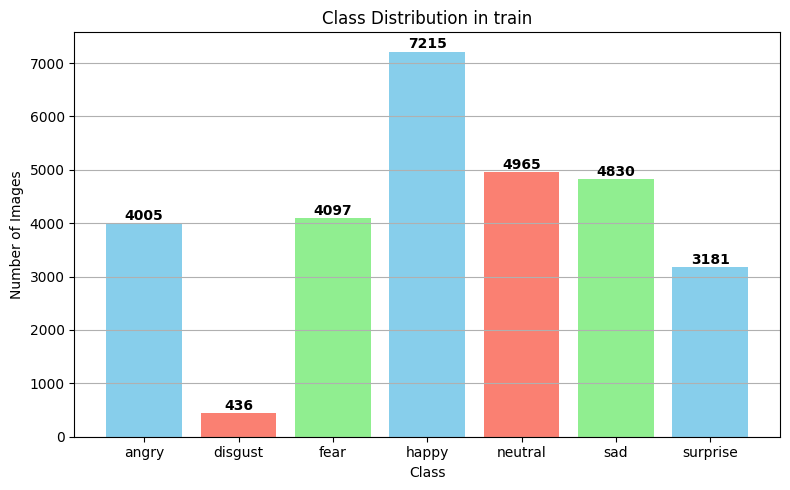

In [6]:


#VISUALING CLASS DISTRIBUTION OF Training IMAGES
base_folder_mask = Trainign_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder_mask, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title(f'Class Distribution in {os.path.basename(base_folder_mask)}')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y')

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 2, str(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# Test Classes

In [7]:

#the base folder
base_folder = Testing_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
counts = {}
total_images = 0 # Initialize a counter for the total number of images

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count
    total_images += count # Add the count from each class to the total

print(f"Total number of images in {Testing_}: {total_images}") # Print the total count

# You can also print the counts per class as before if you still need them
print(counts)

Total number of images in /content/drive/MyDrive/snap_tune_project/original_datasets/test: 7178
{'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


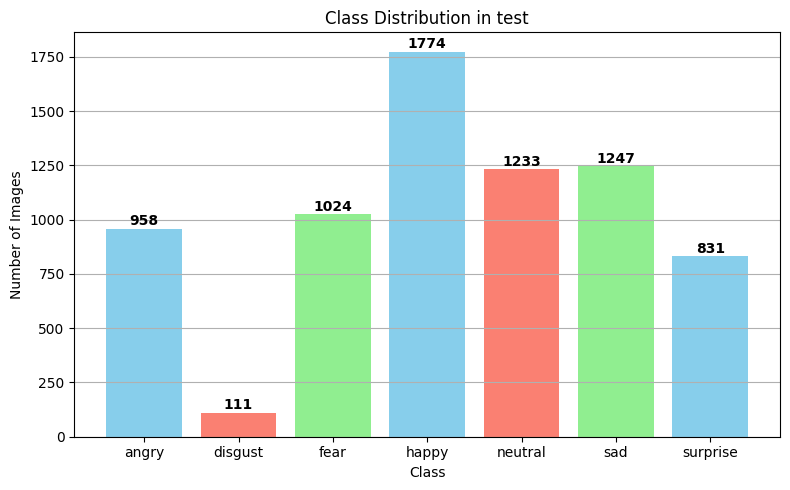

In [8]:


#VISUALING CLASS DISTRIBUTION OF Training IMAGES
base_folder_mask = Testing_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder_mask, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title(f'Class Distribution in {os.path.basename(base_folder_mask)}')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y')

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 2, str(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# VISUALIZING DATA SETS AFTER REMOVING DUPLICATES

TRAINING FOLDER

In [11]:
training_remove_='/content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train'
#the base folder
base_folder = training_remove_

# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
counts = {}
total_images = 0 # Initialize a counter for the total number of images

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count
    total_images += count # Add the count from each class to the total

print(f"Total number of images in {Trainign_}: {total_images}") # Print the total count

#print the counts per class as before if you still need them
print(counts)

Total number of images in /content/drive/MyDrive/snap_tune_project/original_datasets/train: 27473
{'angry': 3849, 'disgust': 381, 'fear': 3904, 'happy': 7086, 'neutral': 4868, 'sad': 4716, 'surprise': 2669}


# Testing Folder

In [12]:
testing_remove_='/content/drive/MyDrive/snap_tune_project/cleaned_fer2013/test'
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
for base_folder, folder_name in [(testing_remove_, 'test')]:
    counts = {}
    total_images = 0
    if not os.path.exists(base_folder):
        print(f"Warning: {base_folder} does not exist. Skipping count.")
        continue
    for cls in emotions:
        class_path = os.path.join(base_folder, cls)
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
        counts[cls] = count
        total_images += count
    print(f"Total number of images in {base_folder}: {total_images}")
    print(f"Counts per class in {folder_name}: {counts}")

Total number of images in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/test: 6561
Counts per class in test: {'angry': 888, 'disgust': 79, 'fear': 922, 'happy': 1711, 'neutral': 1182, 'sad': 1198, 'surprise': 581}


# Preprocessing

In [ ]:
# Install required libraries
!pip install tensorflow scikit-learn opencv-python-headless tqdm -q

import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import resnet50
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from google.colab import drive
import glob

# Step 1: Configuration and Validation
print("Step 1: Setting up configuration and validating dataset...")
config = {
    'data_dir': '/content/drive/MyDrive/snap_tune_project/cleaned_fer2013',
    'img_size': (224, 224),  # ResNet50 input size
    'batch_size': 64,       # Optimized for GPU (T4)
    'chunk_size': 5000,     # Process 5,000 images per chunk
    'train_dir': os.path.join('/content/drive/MyDrive/snap_tune_project/cleaned_fer2013', 'train'),
    'test_dir': os.path.join('/content/drive/MyDrive/snap_tune_project/cleaned_fer2013', 'test')
}

# Preprocessor for ResNet50
def preprocess_image(image):
    if image is None:
        raise ValueError("Image decoding failed, image is None")
    image = tf.image.resize(image, config['img_size'])  # Resize to 224x224
    image.set_shape([224, 224, 1])  # Explicitly set shape (grayscale)
    image = tf.image.grayscale_to_rgb(image)  # Convert to RGB
    image = resnet50.preprocess_input(image)  # Normalize [-1, 1]
    return image

# Mount Google Drive
drive.mount('/content/drive')

# Validate directories
if not os.path.exists(config['data_dir']):
    raise FileNotFoundError(f"Dataset directory {config['data_dir']} does not exist.")
if not os.path.exists(config['train_dir']):
    raise FileNotFoundError(f"Train directory {config['train_dir']} does not exist.")
if not os.path.exists(config['test_dir']):
    raise FileNotFoundError(f"Test directory {config['test_dir']} does not exist.")
print(f"Directories validated: {config['train_dir']}, {config['test_dir']}")

# Define emotion classes
emotion_classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Step 2: Collect Image Paths and Labels for Train Set
print("\nStep 2: Collecting image paths and labels for train set...")
train_image_paths = []
train_labels = []
for class_name in emotion_classes:
    class_dir = os.path.join(config['train_dir'], class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: Class directory {class_dir} is missing. Skipping...")
        continue
    found_files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif']:
        found_files.extend(glob.glob(os.path.join(class_dir, ext)))
    print(f"Found {len(found_files)} files in {class_dir} before verification.")
    if not found_files:
        print(f"Warning: No files found in {class_dir}. Skipping this class.")
        continue
    with tqdm(total=len(found_files), desc=f"Verifying {class_name} (train)") as pbar:
        for img_path in found_files:
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
                train_image_paths.append(img_path)
                train_labels.append(class_name)
            except Exception as e:
                print(f"Skipping corrupted image: {img_path}, Error: {e}")
            pbar.update(1)

train_image_paths = np.array(train_image_paths)
train_labels = np.array(train_labels)

if len(train_image_paths) == 0:
    raise FileNotFoundError(f"No valid images found in {config['train_dir']}.")
print(f"Successfully loaded {len(train_image_paths)} images from train set.")

# Step 3: Split Train Data into Training and Validation Sets
print("\nStep 3: Splitting train data into training and validation sets...")
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
train_paths, val_paths, train_labels_enc, val_labels_enc = train_test_split(
    train_image_paths, train_labels_encoded, train_size=0.7, stratify=train_labels_encoded, random_state=42
)
print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")

# Step 4: Collect Image Paths and Labels for Test Set
print("\nStep 4: Collecting image paths and labels for test set...")
test_image_paths = []
test_labels = []
for class_name in emotion_classes:
    class_dir = os.path.join(config['test_dir'], class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: Test class directory {class_dir} is missing. Skipping...")
        continue
    found_files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif']:
        found_files.extend(glob.glob(os.path.join(class_dir, ext)))
    print(f"Found {len(found_files)} files in {class_dir} before verification.")
    if not found_files:
        print(f"Warning: No files found in {class_dir}. Skipping this class.")
        continue
    with tqdm(total=len(found_files), desc=f"Verifying {class_name} (test)") as pbar:
        for img_path in found_files:
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
                test_image_paths.append(img_path)
                test_labels.append(class_name)
            except Exception as e:
                print(f"Skipping corrupted image: {img_path}, Error: {e}")
            pbar.update(1)

test_image_paths = np.array(test_image_paths)
test_labels = np.array(test_labels)

if len(test_image_paths) == 0:
    raise FileNotFoundError(f"No valid images found in {config['test_dir']}.")
print(f"Successfully loaded {len(test_image_paths)} images from test set.")

# Step 5: Create TFRecord Writing Function
print("\nStep 5: Defining TFRecord writing function...")
def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def create_tfrecord(paths, labels, output_path):
    with tf.io.TFRecordWriter(output_path) as writer:
        for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Writing TFRecord to {output_path}"):
            try:
                img = tf.io.read_file(path)
                img = tf.image.decode_image(img, channels=1, expand_animations=False)
                img = tf.ensure_shape(img, [None, None, 1], name="ensure_image_shape")
                img = preprocess_image(img)
                img_bytes = tf.io.serialize_tensor(img).numpy()
                example = tf.train.Example(features=tf.train.Features(feature={
                    'image': _bytes_feature(img_bytes),
                    'label': _int64_feature(label)
                }))
                writer.write(example.SerializeToString())
            except Exception as e:
                print(f"Skipping invalid image: {path}, Error: {e}")

# Step 6: Process and Save Datasets in Chunks
print("\nStep 6: Processing and saving datasets in chunks...")
def process_in_chunks(paths, labels, dataset_type, preprocessed_dir):
    num_chunks = max(1, len(paths) // config['chunk_size'] + 1)
    for i in range(num_chunks):
        start_idx = i * config['chunk_size']
        end_idx = min((i + 1) * config['chunk_size'], len(paths))
        chunk_paths = paths[start_idx:end_idx]
        chunk_labels = labels[start_idx:end_idx]
        if len(chunk_paths) == 0:
            continue
        chunk_output = os.path.join(preprocessed_dir, f'{dataset_type}_chunk_{i}.tfrecord')
        print(f"Processing {dataset_type} chunk {i+1}/{num_chunks} ({len(chunk_paths)} images)...")
        create_tfrecord(chunk_paths, chunk_labels, chunk_output)
    print(f"Finished processing {dataset_type} dataset.")

# Create preprocessed directory
preprocessed_dir = os.path.join(config['data_dir'], 'preprocessed')
os.makedirs(preprocessed_dir, exist_ok=True)

# Process train, validation, and test datasets
try:
    process_in_chunks(train_paths, train_labels_enc, 'train', preprocessed_dir)
    process_in_chunks(val_paths, val_labels_enc, 'val', preprocessed_dir)
    process_in_chunks(test_image_paths, le.transform(test_labels), 'test', preprocessed_dir)
except Exception as e:
    print(f"Error processing chunks: {e}")
    print("Check disk space in Google Drive or /tmp, or reduce chunk_size.")

# Step 7: Compute Class Weights
print("\nStep 7: Computing class weights...")
class_weights = np.zeros(len(emotion_classes))
for label in train_labels_enc:
    class_weights[label] += 1
class_weights = len(train_labels_enc) / (len(emotion_classes) * class_weights)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Class weights: {class_weight_dict}")

# Step 8: Save Class Weights and Label Encoder
print("\nStep 8: Saving class weights and label encoder...")
try:
    np.save(os.path.join(preprocessed_dir, 'class_weights.npy'), class_weight_dict)
    np.save(os.path.join(preprocessed_dir, 'label_encoder.npy'), le.classes_)
    print("Class weights and label encoder saved successfully.")
except Exception as e:
    print(f"Error saving metadata: {e}")

print("Preprocessing completed successfully.")

Step 1: Setting up configuration and validating dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directories validated: /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train, /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/test

Step 2: Collecting image paths and labels for train set...
Found 3849 files in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train/angry before verification.


Verifying angry (train): 100%|██████████| 3849/3849 [00:39<00:00, 98.62it/s] 


Found 381 files in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train/disgust before verification.


Verifying disgust (train): 100%|██████████| 381/381 [00:01<00:00, 253.77it/s]


Found 3904 files in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train/fear before verification.


...

Writing TFRecord to /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/val_chunk_0.tfrecord: 100%|██████████| 5000/5000 [01:09<00:00, 71.82it/s]


Processing val chunk 2/2 (3242 images)...


Writing TFRecord to /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/val_chunk_1.tfrecord: 100%|██████████| 3242/3242 [00:47<00:00, 68.77it/s]


Finished processing val dataset.
Processing test chunk 1/2 (5000 images)...


Writing TFRecord to /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/test_chunk_0.tfrecord:  33%|███▎      | 1671/5000 [14:01<55:16,  1.00it/s]

#RESNET MODEL TRAINING

In [ ]:
# Install required libraries
!pip install tensorflow scikit-learn -q

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# Load preprocessed data
preprocessed_dir = '/content/drive/MyDrive/snap_tune_project/preprocessed'
X_train = np.load(os.path.join(preprocessed_dir, 'X_train_processed.npy'))
y_train = np.load(os.path.join(preprocessed_dir, 'y_train_one_hot.npy'))
X_val = np.load(os.path.join(preprocessed_dir, 'X_val_processed.npy'))
y_val = np.load(os.path.join(preprocessed_dir, 'y_val_one_hot.npy'))
X_test = np.load(os.path.join(preprocessed_dir, 'X_test_processed.npy'))
y_test = np.load(os.path.join(preprocessed_dir, 'y_test_one_hot.npy'))

# Define emotions for confusion matrix labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Define class weights (from preprocessing output)
class_weights = {
    0: 1.0197794039664865,  # angry
    1: 10.289459604066346,  # disgust
    2: 1.0052271182896868,  # fear
    3: 0.5538882488479263,  # happy
    4: 0.8061284372904092,  # neutral
    5: 0.832258622928117,   # sad
    6: 1.4707096971550933   # surprise
}

# Load the pre-built model
models_dir = '/content/drive/MyDrive/snap_tune_project/models'
model_path = os.path.join(models_dir, 'resnet50_emotion_untrained.h5')
model = load_model(model_path)

# Compile the model (recompile to ensure consistency)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train the model
print("Starting model training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stopping]
)

# Evaluate on validation set
val_pred = model.predict(X_val)
val_pred_classes = np.argmax(val_pred, axis=1)
val_true_classes = np.argmax(y_val, axis=1)
val_weighted_f1 = f1_score(val_true_classes, val_pred_classes, average='weighted')
val_cm = confusion_matrix(val_true_classes, val_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title('Validation Confusion Matrix')
plt.savefig(os.path.join(models_dir, 'val_cm.png'))
plt.close()

print(f"Validation Weighted F1: {val_weighted_f1:.4f}")

# Evaluate on test set
print("Evaluating on test set...")
test_pred = model.predict(X_test)
test_pred_classes = np.argmax(test_pred, axis=1)
test_true_classes = np.argmax(y_test, axis=1)
test_weighted_f1 = f1_score(test_true_classes, test_pred_classes, average='weighted')
test_cm = confusion_matrix(test_true_classes, test_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title('Test Confusion Matrix')
plt.savefig(os.path.join(models_dir, 'test_cm.png'))
plt.close()

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}, Test Weighted F1: {test_weighted_f1:.4f}")

# Save the trained model
trained_model_path = os.path.join(models_dir, 'resnet50_emotion_trained.h5')
model.save(trained_model_path)
print(f"Trained model saved to {trained_model_path}")